# Student Churn Prediction

**Objectif:**
 - Connaître la structure du dataset pour pouvoir choisir les variables pertinentes afin de construire un modèle prédictif.

## 1. Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
raw_path = "../data/raw/dropout.csv" 
df_raw = pd.read_csv(raw_path)

print(df_raw.shape)

(4424, 37)


## 2. Description des variables

Une description de chaque variable.

In [3]:
type_summary = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
})
type_summary["exemple_valeurs"] = [
    sorted(df_raw[col].dropna().unique())[:6] for col in df_raw.columns
]
type_summary.sort_values("n_unique", ascending=False)

,dtype,n_unique,n_missing,exemple_valeurs
Curricular units 1st sem (grade),float64,797,0,"[0.0, 9.8, 10.0, 10.16666667, 10.2, 10.21428571]"
Curricular units 2nd sem (grade),float64,782,0,"[0.0, 10.0, 10.16666667, 10.2, 10.25, 10.33333..."
Admission grade,float64,620,0,"[95.0, 95.1, 95.5, 95.8, 96.0, 96.1]"
Previous qualification (grade),float64,101,0,"[95.0, 96.0, 97.0, 99.0, 100.0, 101.0]"
Father's occupation,int64,46,0,"[0, 1, 2, 3, 4, 5]"
Age at enrollment,int64,46,0,"[17, 18, 19, 20, 21, 22]"
Curricular units 1st sem (evaluations),int64,35,0,"[0, 1, 2, 3, 4, 5]"
Father's qualification,int64,34,0,"[1, 2, 3, 4, 5, 6]"
Mother's occupation,int64,32,0,"[0, 1, 2, 3, 4, 5]"
Curricular units 2nd sem (evaluations),int64,30,0,"[0, 1, 2, 3, 4, 5]"


Summary: 
- Aucune valeur manquante détectée.
- Les colonnes `int64` à faible cardinalité sont en réalité des codes catégoriels et non des quantités.

In [4]:
num_continuous = [
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)",
    "Admission grade", "Previous qualification (grade)",
    "Unemployment rate", "GDP", "Inflation rate",
]
num_discrete = [
    "Age at enrollment",
    "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (without evaluations)",
]
cat_binary = [
    "Daytime/evening attendance", "International", "Gender", "Scholarship holder",
    "Educational special needs", "Debtor", "Displaced", "Tuition fees up to date",
]
cat_nominal = [
    "Father's occupation", "Mother's occupation", "Father's qualification",
    "Mother's qualification", "Nacionality", "Application mode",
    "Previous qualification", "Course", "Marital Status",
]
cat_ordinal = ["Application order"]

print(len(num_continuous + num_discrete + cat_binary + cat_nominal + cat_ordinal) + 1 == df_raw.shape[1])

True


## 3. Analyse univariée

### 1- Variables numériques

Pour chaque variable numérique (continue et discrète), on calcule moyenne, médiane, écart-type, et le nombre de valeurs aberrantes.
L'objectif est d'identifier les variables asymétriques et les colonnes où les valeurs extrêmes pourraient représenter un signal réel.

In [5]:
num_cols = num_continuous + num_discrete

#iqr method to detect outliers
def outlier_count(s: pd.Series) -> int:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

univariate_num = pd.DataFrame({
    "mean" : df_raw[num_cols].mean(),
    "median" : df_raw[num_cols].median(),
    "std" : df_raw[num_cols].std(),
    "min" : df_raw[num_cols].min(),
    "max" : df_raw[num_cols].max(),
    "skew" : df_raw[num_cols].skew(),
    "outliers" : df_raw[num_cols].apply(outlier_count)
})
univariate_num.sort_values("skew", ascending=False)

,mean,median,std,min,max,skew,outliers
Curricular units 1st sem (without evaluations),0.137658,0.000000,0.690880,0.00,12.000000,8.207403,294
Curricular units 2nd sem (without evaluations),0.150316,0.000000,0.753774,0.00,12.000000,7.267701,282
Curricular units 2nd sem (credited),0.541817,0.000000,1.918546,0.00,19.000000,4.634820,530
Curricular units 1st sem (credited),0.709991,0.000000,2.360507,0.00,20.000000,4.169049,577
Age at enrollment,23.265145,20.000000,7.587816,17.00,70.000000,2.054988,441
Curricular units 1st sem (enrolled),6.270570,6.000000,2.480178,0.00,26.000000,1.619041,424
Curricular units 1st sem (evaluations),8.299051,8.000000,4.179106,0.00,45.000000,0.976637,158
Curricular units 2nd sem (enrolled),6.232143,6.000000,2.195951,0.00,23.000000,0.788114,369
Curricular units 1st sem (approved),4.706600,5.000000,3.094238,0.00,26.000000,0.766262,180
Admission grade,126.978119,126.100000,14.482001,95.00,190.000000,0.530600,86


- **Visualisation des distributions**

On trace un histogramme par variable numérique (avec la médiane en repère) afin de confirmer visuellement les hypothèses issues des statistiques univariées :
 > Distributions à inflation de zéros pour les colonnes "credited"/"without evaluations".
 
 > Nature bimodale potentielle des colonnes de notes (0 = probablement "aucune évaluation", pas "note nulle").


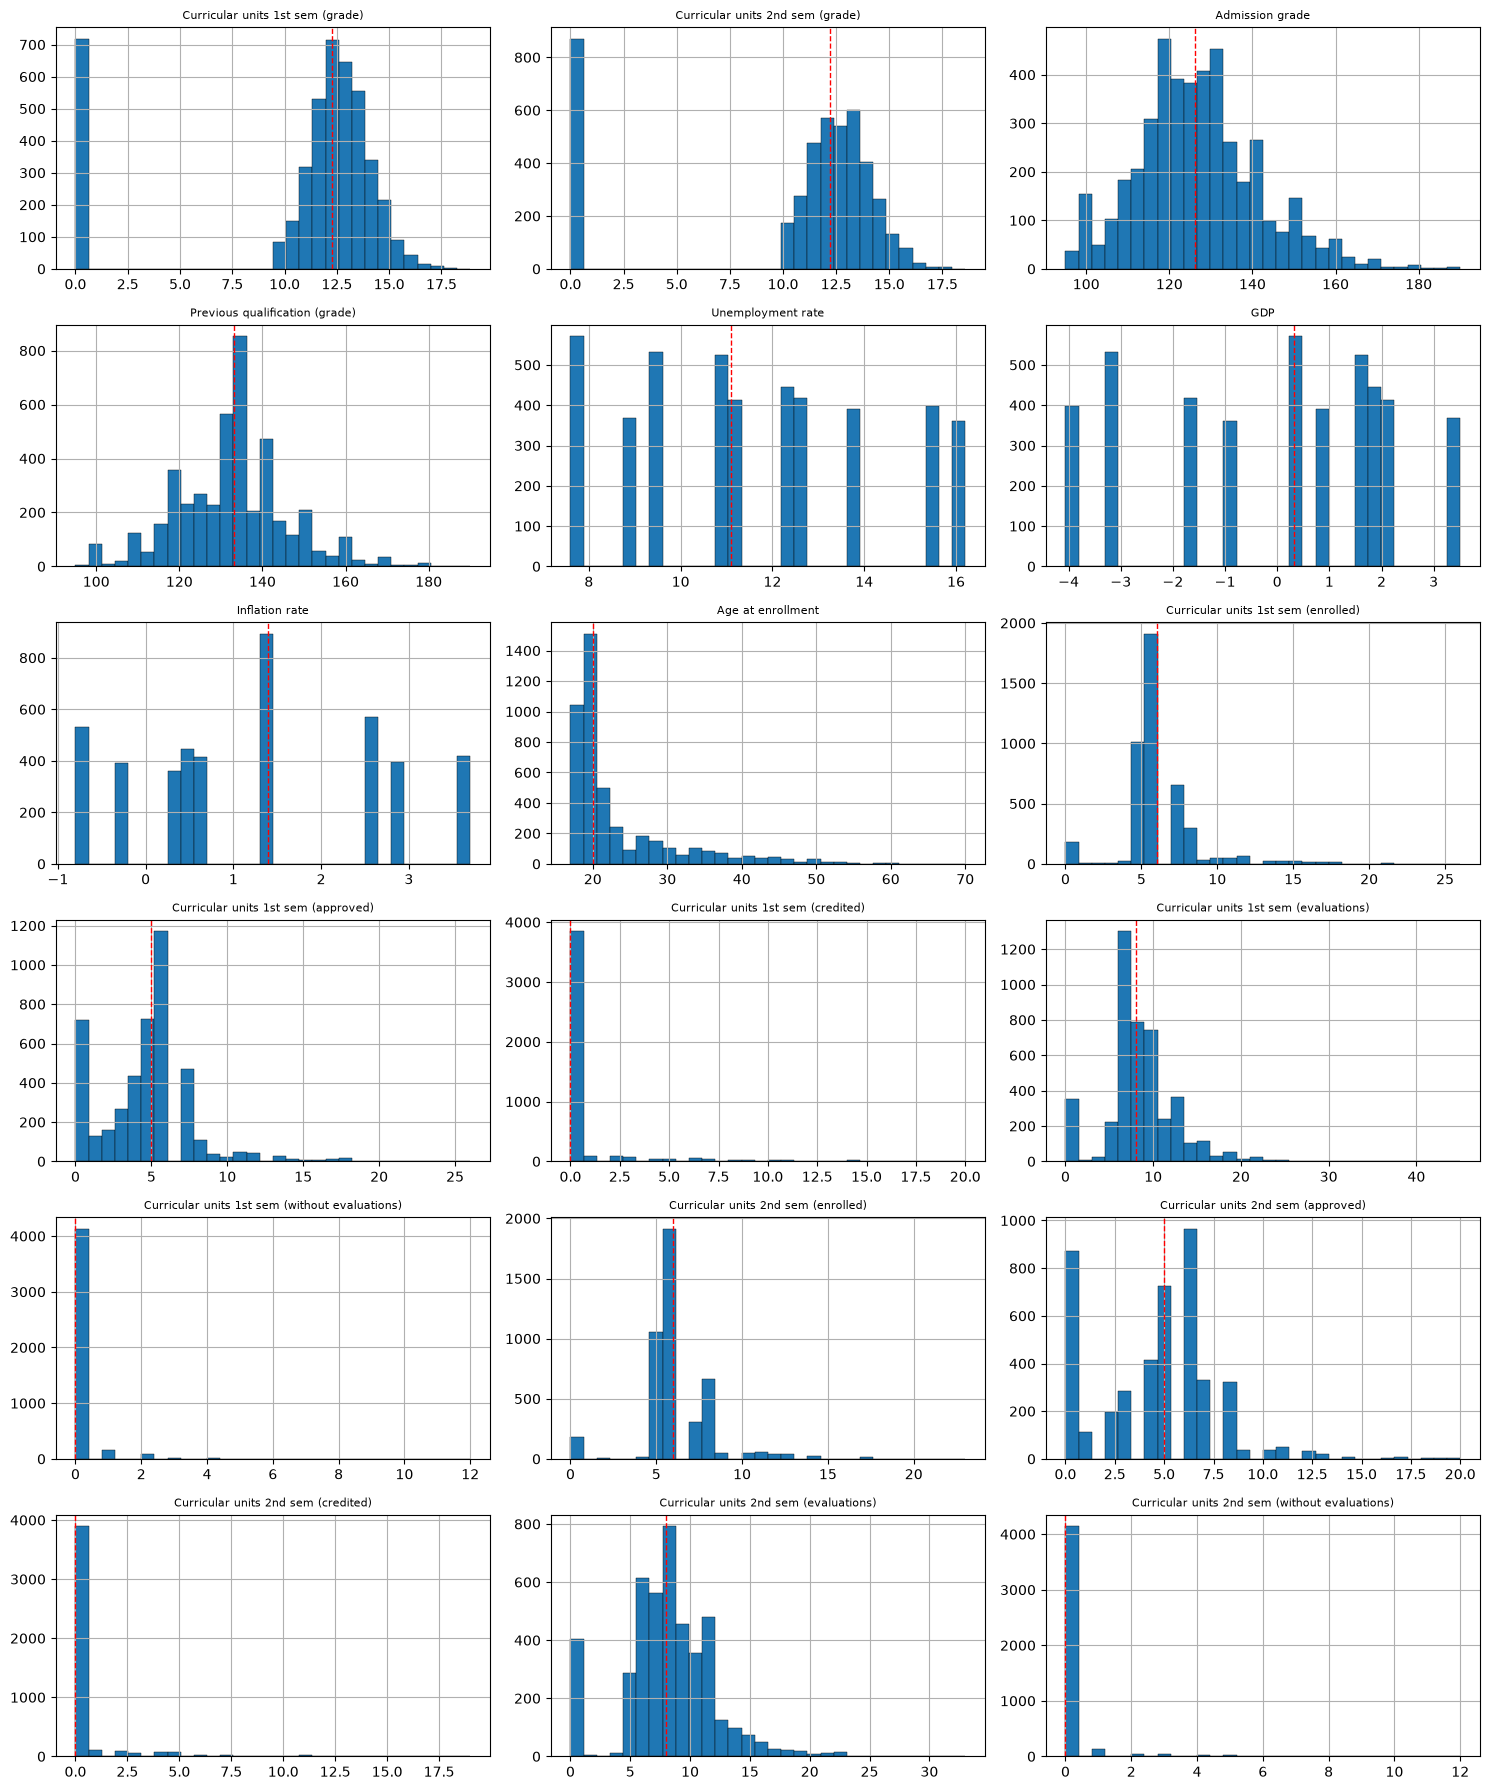

In [6]:
fig, axes = plt.subplots(6, 3, figsize=(15, 18))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df_raw[col].hist(bins=30, ax=ax, edgecolor="black", linewidth=0.3)
    ax.axvline(df_raw[col].median(), color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=8)

for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# checking for correlation between "Curricular units 1st sem (grade)" and "Curricular units 1st sem (evaluations)"
pd.crosstab(
    df_raw["Curricular units 1st sem (grade)"] == 0,
    df_raw["Curricular units 1st sem (evaluations)"] == 0,
)

Curricular units 1st sem (evaluations),False,True
Curricular units 1st sem (grade),,
False,3706,0
True,369,349


In [8]:
# checking for correlation between "Curricular units 2nd sem (grade)" and "Curricular units 2nd sem (evaluations)"
pd.crosstab(
    df_raw["Curricular units 2nd sem (grade)"] == 0,
    df_raw["Curricular units 2nd sem (evaluations)"] == 0,
)

Curricular units 2nd sem (evaluations),False,True
Curricular units 2nd sem (grade),,
False,3554,0
True,469,401


### 2- Variables catégorielles

Pour chaque variable catégorielle (binaire et nominale), on calcule les fréquences absolues et relatives.

In [9]:
cat_cols = cat_binary + cat_nominal

# Tableau de fréquence et proportion pour les variables catégorielles
for col in cat_cols + ["Target"]:
    freq = df_raw[col].value_counts()
    prop = df_raw[col].value_counts(normalize=True)
    print(f"\n   {col} ({df_raw[col].nunique()} modalités) ")
    display(pd.DataFrame({"fréquence": freq, "proportion": (prop * 100).round(2)}))

rare_categories = {
    col: df_raw[col].value_counts(normalize=True)[lambda p: p<0.01].index.tolist()
    for col in cat_cols
    if (df_raw[col].value_counts(normalize=True) < 0.01).any()
}
print("Les catégories rares :")
rare_categories


   Daytime/evening attendance (2 modalités) 


,fréquence,proportion
Daytime/evening attendance,,
1,3941,89.08
0,483,10.92



   International (2 modalités) 


,fréquence,proportion
International,,
0,4314,97.51
1,110,2.49



   Gender (2 modalités) 


...

,fréquence,proportion
Marital Status,,
1,3919,88.58
2,379,8.57
4,91,2.06
5,25,0.57
6,6,0.14
3,4,0.09



   Target (3 modalités) 


,fréquence,proportion
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


Les catégories rares :


{"Father's occupation": [99,
  193,
  144,
  171,
  192,
  163,
  175,
  103,
  135,
  152,
  183,
  181,
  123,
  151,
  182,
  194,
  172,
  122,
  102,
  112,
  124,
  121,
  195,
  161,
  132,
  131,
  143,
  134,
  153,
  174,
  141,
  114,
  101,
  154],
 "Mother's occupation": [8,
  191,
  99,
  194,
  141,
  123,
  144,
  175,
  192,
  134,
  10,
  193,
  151,
  132,
  143,
  152,
  122,
  153,
  125,
  173,
  131,
  171],
 "Father's qualification": [4,
  12,
  39,
  5,
  11,
  36,
  9,
  40,
  14,
  22,
  30,
  29,
  26,
  35,
  41,
  43,
  10,
  6,
  20,
  13,
  18,
  42,
  25,
  44,
  33,
  27,
  31],
 "Mother's qualification": [12,
  5,
  40,
  9,
  39,
  41,
  42,
  6,
  43,
  11,
  30,
  35,
  36,
  10,
  29,
  14,
  18,
  22,
  27,
  26,
  44],
 'Nacionality': [41,
  26,
  6,
  22,
  24,
  103,
  11,
  100,
  62,
  25,
  21,
  101,
  2,
  105,
  13,
  32,
  109,
  108,
  14,
  17],
 'Application mode': [16, 53, 15, 5, 10, 2, 57, 26, 27],
 'Previous qualification': [40, 4

## 3. Analyse bivariée

On restreint l'analyse bivariée aux variables disponibles au moment de la décision (semestre 1 et admission), car un modèle d'alerte précoce ne dispose pas des données du semestre 2 pour un étudiant encore inscrit. La cible est binarisée (Dropout/Graduate), les lignes "Enrolled" étant exclues car leur issue est encore indéterminée.

churn_target
0    0.60854
1    0.39146
Name: proportion, dtype: float64


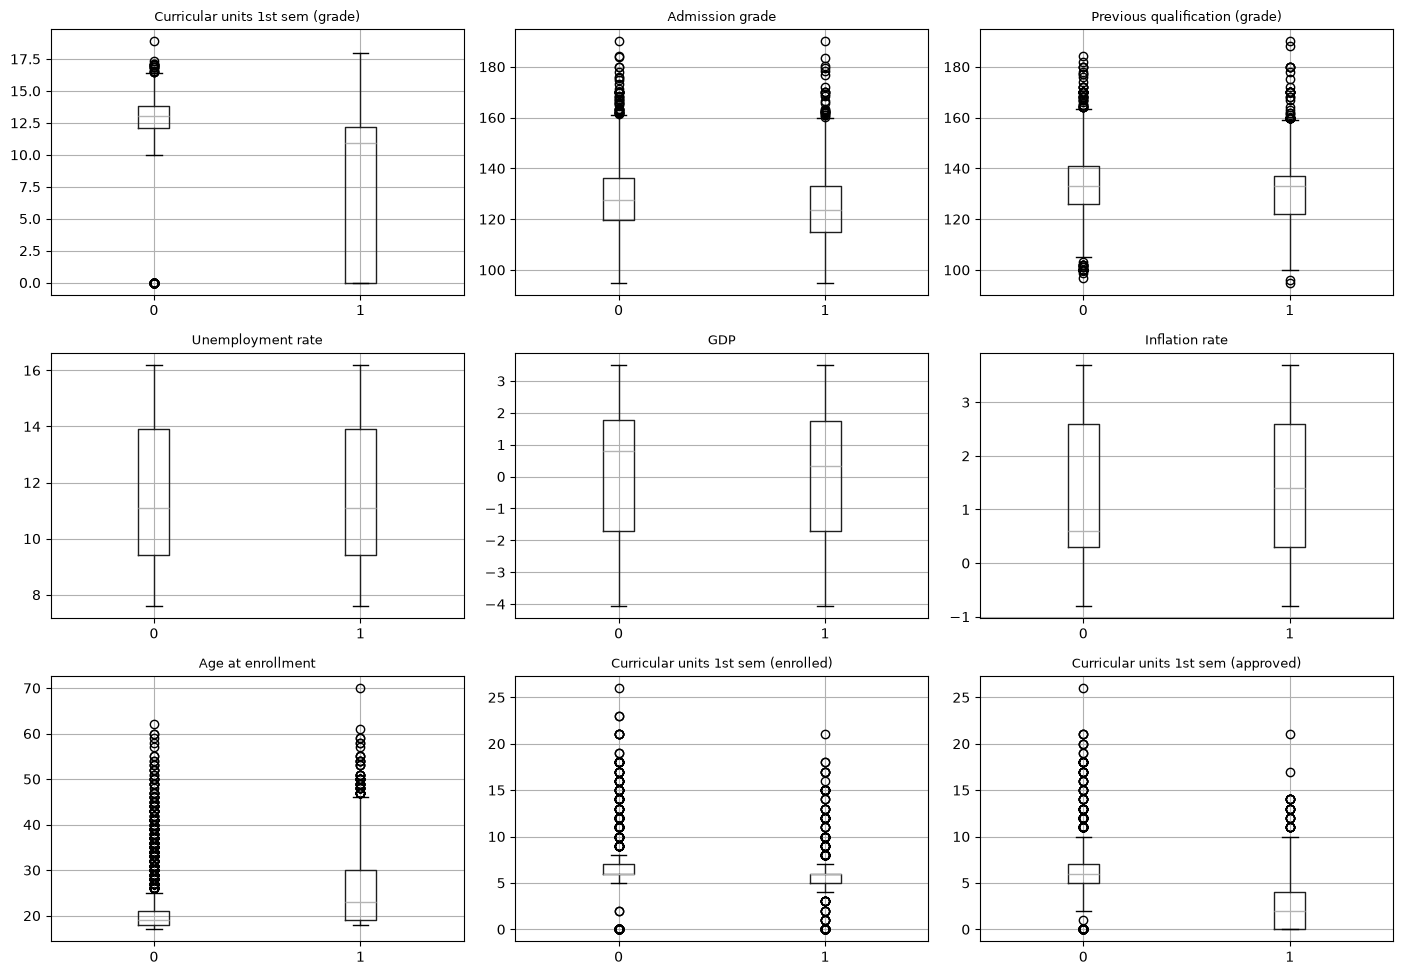

In [10]:
churn_df = df_raw[df_raw["Target"].isin(["Dropout", "Graduate"])].copy()
churn_df["churn_target"] = churn_df["Target"].map({"Dropout": 1, "Graduate": 0})

print(churn_df["churn_target"].value_counts(normalize=True))

sem1_numeric = [c for c in num_continuous + num_discrete if "2nd sem" not in c]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, sem1_numeric):
    churn_df.boxplot(column=col, by="churn_target", ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()


- Quantification de la séparation: 

On calcule la différence de moyenne standardisée (Cohen's d) entre Dropout et Graduate pour chaque variable numérique disponible au moment de la décision, afin de classer objectivement les variables par pouvoir discriminant.

>   ~  0  : pas d'effet.

> \>= 0.2 : effet petit.

> \>= 0.5 : effet moyen.

> \>= 0.8 : effet large.

In [11]:
def cohens_d(group0, group1):
    n0, n1 = len(group0), len(group1)
    pooled_std = np.sqrt(((n0 - 1) * group0.std()**2 + (n1 - 1) * group1.std()**2) / (n0 + n1 - 2))
    return (group1.mean() - group0.mean()) / pooled_std

effect_sizes = {
    col: cohens_d(
        churn_df.loc[churn_df["churn_target"] == 0, col],
        churn_df.loc[churn_df["churn_target"] == 1, col],
    )
    for col in sem1_numeric
}
pd.Series(effect_sizes).sort_values(key=abs, ascending=False)

Curricular units 1st sem (approved)              -1.366171
Curricular units 1st sem (grade)                 -1.246722
Age at enrollment                                 0.568021
Curricular units 1st sem (enrolled)              -0.334291
Admission grade                                  -0.264477
Previous qualification (grade)                   -0.225569
Curricular units 1st sem (without evaluations)    0.153317
Curricular units 1st sem (evaluations)           -0.122679
GDP                                              -0.103078
Curricular units 1st sem (credited)              -0.096171
Inflation rate                                    0.062145
Unemployment rate                                -0.008599
dtype: float64

In [12]:
# Tableau de contingence pour les variables catégorielles:
for col in cat_binary:
    print(f"\nVariable: {col}")
    display(pd.crosstab(churn_df[col], churn_df["churn_target"], normalize="index").round(3))

for col in cat_nominal:
    grp = churn_df.groupby(col)["churn_target"].agg(["mean", "count"])
    grp = grp[grp["count"] >= 30].sort_values("mean", ascending=False)
    print(f"\n {col} (catégories avec n>=30)")
    display(grp)


Variable: Daytime/evening attendance


churn_target,0,1
Daytime/evening attendance,,
0,0.493,0.507
1,0.623,0.377



Variable: International


churn_target,0,1
International,,
0,0.608,0.392
1,0.628,0.372



Variable: Gender


...

,mean,count
Previous qualification,,
19,0.697987,149
12,0.666667,39
3,0.614754,122
39,0.420732,164
40,0.411765,34
1,0.357072,3019



 Course (catégories avec n>=30)


,mean,count
Course,,
9119,0.867925,106
9130,0.650000,120
9991,0.635514,214
9853,0.598592,142
9003,0.497110,173
9147,0.492647,272
9556,0.478261,69
171,0.460674,178
9254,0.454976,211



 Marital Status (catégories avec n>=30)


,mean,count
Marital Status,,
4,0.560000,75
2,0.547401,327
1,0.370116,3199


- Khi-2 et V de Cramér:


In [13]:
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2, p, dof, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)), p

results = {}
for col in cat_binary + cat_nominal:
    ct = pd.crosstab(churn_df[col], churn_df["churn_target"])
    v, p = cramers_v(ct)
    results[col] = {"cramers_v": v, "p_value": p}

pd.DataFrame(results).T.sort_values("cramers_v", ascending=False)

,cramers_v,p_value
Tuition fees up to date,0.441309,9.189124e-156
Course,0.349320,3.497695e-84
Application mode,0.328644,8.435153e-73
Scholarship holder,0.312380,5.109075e-79
Debtor,0.266318,6.141424e-58
Gender,0.251361,8.255974e-52
Previous qualification,0.203684,5.952453e-24
Father's qualification,0.201825,1.754550e-16
Mother's qualification,0.198489,2.201217e-17
Mother's occupation,0.195144,1.555138e-16


## 4. Corrélation et multicolinéarité

On calcule la matrice de corrélation de Pearson entre les variables numériques, afin de détecter les paires fortement corrélées, avant construction de variables dérivées ou entraînement d'un modèle linéaire.

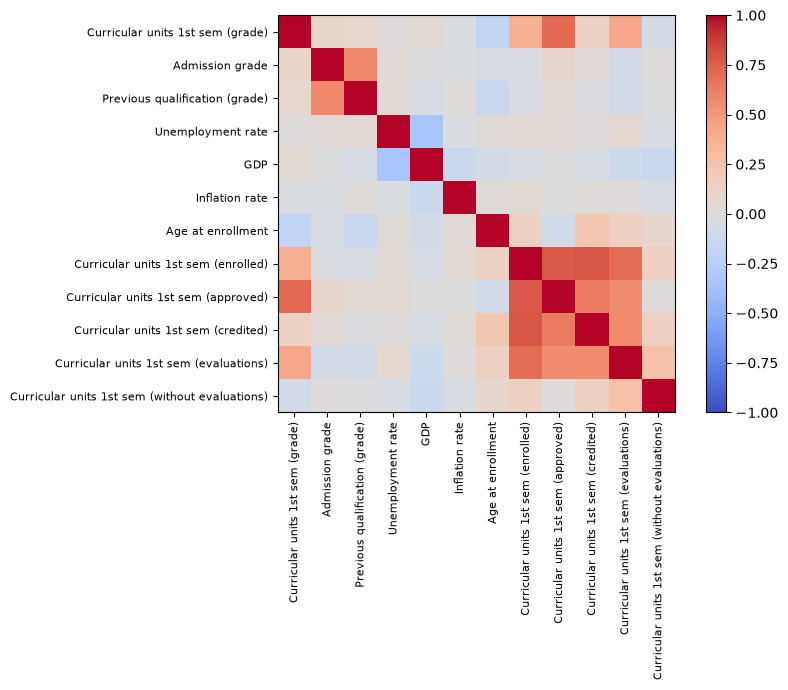

Curricular units 1st sem (enrolled)  Curricular units 1st sem (credited)       0.782863
                                     Curricular units 1st sem (approved)       0.773579
Curricular units 1st sem (grade)     Curricular units 1st sem (approved)       0.710157
Curricular units 1st sem (enrolled)  Curricular units 1st sem (evaluations)    0.697723
Curricular units 1st sem (approved)  Curricular units 1st sem (credited)       0.636071
Admission grade                      Previous qualification (grade)            0.577241
Curricular units 1st sem (credited)  Curricular units 1st sem (evaluations)    0.569178
Curricular units 1st sem (approved)  Curricular units 1st sem (evaluations)    0.559969
dtype: float64

In [14]:
corr_matrix = churn_df[sem1_numeric].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(sem1_numeric)))
ax.set_yticks(range(len(sem1_numeric)))
ax.set_xticklabels(sem1_numeric, rotation=90, fontsize=8)
ax.set_yticklabels(sem1_numeric, fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.show()

high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
high_corr[abs(high_corr) > 0.5]

## 5. Synthèse

- **Variables à fort pouvoir discriminant** (à conserver en priorité) : `Curricular units 1st sem (approved)` et `(grade)` (effet large, Cohen's d > 1.2), `Age at enrollment` (effet modéré), `Tuition fees up to date`, `Debtor`, `Scholarship holder`, `Course`, `Application mode` (V de Cramér > 0.25).

- **Variables à écarter** (signal négligeable) : `Unemployment rate`, `GDP`, `Inflation rate`,`International`, `Educational special needs`, `Nacionality` (p > 0.05).

- **Redondance à traiter** : `enrolled`/`approved`/`credited`/`evaluations` du 1er semestre sont fortement corrélées (r > 0.55) ; conserver le ratio d'efficacité plutôt que les variables brutes en parallèle.

- **Feature à construire** : statut d'évaluation à 3 modalités (aucune évaluation / évaluée à zéro / note positive), les deux premiers cas ayant des taux de décrochage vraisemblablement différents.

- **Méthodologie** : cible restreinte à Dropout/Graduate (`Enrolled` exclu, issue non résolue) ; déséquilibre modéré (~39%/61%) gérable par pondération de classe plutôt que sur-échantillonnage ; seules les variables disponibles au semestre 1 et à l'admission seront utilisées comme features, le semestre 2 étant réservé à la validation a posteriori.